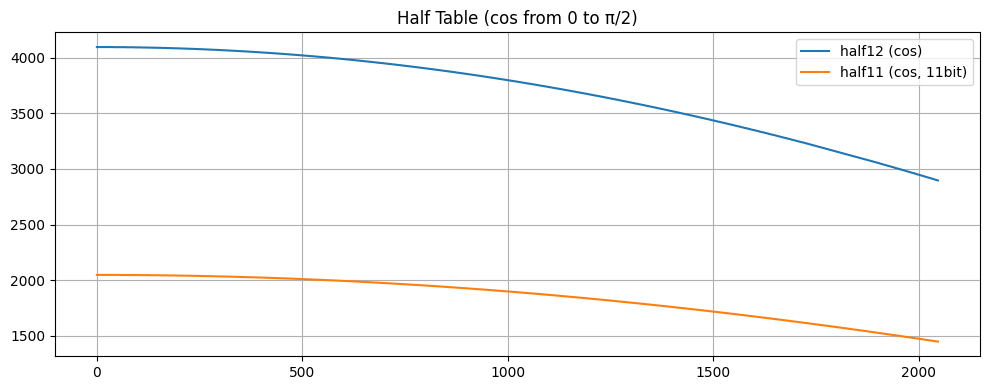

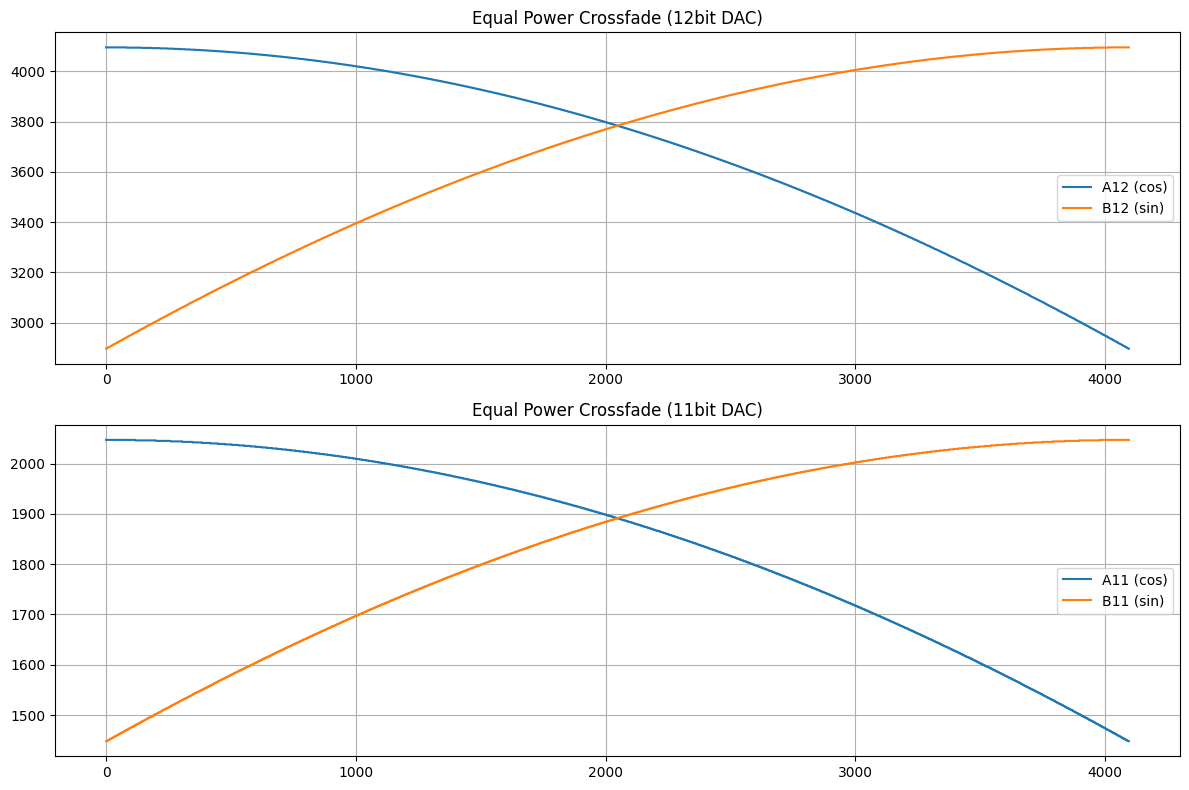

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ---------------------------------------------------------
# CrossFader (12bit DAC) と CrossFader11 (11bit DAC)
# ---------------------------------------------------------

N_FULL = 4096
N_HALF = 2048

DAC12_MAX = 4095
DAC11_MAX = 2047


def generate_half_table(dac_max):
    half = np.zeros(N_HALF, dtype=np.uint16)
    for i in range(N_HALF):
        x = i / (N_HALF - 1)
        theta = x * (math.pi / 2.0)
        g = math.cos(theta)
        half[i] = int(round(g * dac_max))
    return half


def gainA(n, half):
    # n = 0..4095 を 0..2047 に縮小
    i = n >> 1   # 4096→2048 にスケールダウン
    return half[i]

def gainB(n, half):
    # B は A の逆向き
    return gainA(N_FULL - 1 - n, half)

# ---------------------------------------------------------
# テーブル生成
# ---------------------------------------------------------

half12 = generate_half_table(DAC12_MAX)
half11 = generate_half_table(DAC11_MAX)

# フルレンジの A/B を生成
A12 = np.array([gainA(n, half12) for n in range(N_FULL)])
B12 = np.array([gainB(n, half12) for n in range(N_FULL)])

A11 = np.array([gainA(n, half11) for n in range(N_FULL)])
B11 = np.array([gainB(n, half11) for n in range(N_FULL)])


# ---------------------------------------------------------
# half-table の形を確認するためのグラフ
# ---------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.title("Half Table (cos from 0 to π/2)")
plt.plot(np.arange(N_HALF), half12, label="half12 (cos)")
plt.plot(np.arange(N_HALF), half11, label="half11 (cos, 11bit)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# グラフ描画
# ---------------------------------------------------------

x = np.arange(N_FULL)

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.title("Equal Power Crossfade (12bit DAC)")
plt.plot(x, A12, label="A12 (cos)")
plt.plot(x, B12, label="B12 (sin)")
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.title("Equal Power Crossfade (11bit DAC)")
plt.plot(x, A11, label="A11 (cos)")
plt.plot(x, B11, label="B11 (sin)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()